First Cell it applying Filter of NYSE and Value of Stocks requested

In [77]:
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import GetAssetsRequest
from alpaca.trading.enums import AssetClass, AssetStatus

from alpaca.data import StockHistoricalDataClient, StockBarsRequest
from alpaca.data.timeframe import TimeFrame

API_KEY = "PKHJB3YT6BXSYPUH2BWSQNRXLL"
API_SECRET = "EVQaHrtHuabd2MwatcY72dT7zyg6GKshU2fG5hMN4hNS"

trading_client = TradingClient(API_KEY, API_SECRET)
data_client = StockHistoricalDataClient(API_KEY, API_SECRET)

# 1) Get all active US equities on NYSE
assets_req = GetAssetsRequest(
    status=AssetStatus.ACTIVE,
    asset_class=AssetClass.US_EQUITY
)

all_assets = trading_client.get_all_assets(assets_req)

nyse_symbols = [
    a.symbol
    for a in all_assets
    if a.exchange == "NYSE" and a.tradable
]

print(f"NYSE tradable count: {len(nyse_symbols)}")

# 2) Get a recent close price and filter to < $25
end = datetime.today()
start = end - timedelta(days=10)   # buffer in case of holidays

def get_latest_close(symbols):
    """Return last available close for each symbol in `symbols`."""
    req = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=TimeFrame.Day,
        start=start,
        end=end,
    )
    bars = data_client.get_stock_bars(req).df
    # bars index: (symbol, timestamp)
    # take last bar per symbol
    last = bars.groupby(level=0).tail(1)['close']
    return last

# Chunk to avoid huge single request
chunk_size = 200
closes_list = []

for i in range(0, len(nyse_symbols), chunk_size):
    chunk = nyse_symbols[i:i+chunk_size]
    try:
        last = get_latest_close(chunk)
        closes_list.append(last)
    except Exception as e:
        print("Error on chunk", i, e)

closes = pd.concat(closes_list)
closes = closes.dropna()

universe = closes[closes < 25].index.tolist()
print(f"Universe size (NYSE, price < $25): {len(universe)}")


NYSE tradable count: 2887
Universe size (NYSE, price < $25): 1589


In [78]:
import pandas as pd
from datetime import datetime, timedelta

from alpaca.trading.client import TradingClient
from alpaca.trading.requests import GetAssetsRequest
from alpaca.trading.enums import AssetClass, AssetStatus

from alpaca.data import StockHistoricalDataClient, StockBarsRequest
from alpaca.data.timeframe import TimeFrame

# === CONFIG ===
API_KEY = "PKHJB3YT6BXSYPUH2BWSQNRXLL"
API_SECRET = "EVQaHrtHuabd2MwatcY72dT7zyg6GKshU2fG5hMN4hNS"

trading_client = TradingClient(API_KEY, API_SECRET)
data_client = StockHistoricalDataClient(API_KEY, API_SECRET)

# 1) Get all active US equities on NYSE
assets_req = GetAssetsRequest(
    status=AssetStatus.ACTIVE,
    asset_class=AssetClass.US_EQUITY
)

all_assets = trading_client.get_all_assets(assets_req)

nyse_symbols = [
    a.symbol
    for a in all_assets
    if a.exchange == "NYSE" and a.tradable
]

print(f"NYSE tradable count: {len(nyse_symbols)}")

# 2) Get a recent close price and filter to < $25
end_latest = datetime.today()
start_latest = end_latest - timedelta(days=10)   # buffer in case of holidays

def get_latest_close(symbols):
    """Return last available close for each symbol in `symbols` (index = symbol)."""
    if not symbols:
        return pd.Series(dtype=float)

    req = StockBarsRequest(
        symbol_or_symbols=symbols,
        timeframe=TimeFrame.Day,
        start=start_latest,
        end=end_latest,
    )
    bars = data_client.get_stock_bars(req).df

    if bars.empty:
        return pd.Series(dtype=float)

    # bars index: (symbol, timestamp)
    # -> take last close per symbol, index = symbol (no MultiIndex)
    last = bars['close'].groupby(level=0).last()
    return last

# Chunk to avoid huge single request
chunk_size = 200
closes_list = []

for i in range(0, len(nyse_symbols), chunk_size):
    chunk = nyse_symbols[i:i + chunk_size]
    try:
        last = get_latest_close(chunk)
        closes_list.append(last)
        print(f"Got latest closes for chunk {i // chunk_size + 1}")
    except Exception as e:
        print("Error on chunk", i, e)

closes = pd.concat(closes_list)
closes = closes.dropna()

# Universe: NYSE stocks with last close < $25
universe = closes[closes < 25].index.astype(str).tolist()
print(f"Universe size (NYSE, price < $25): {len(universe)}")
print("First few symbols in universe:", universe[:10])

# 3) Get 3 years of daily history for this universe
hist_end = datetime.today()
hist_start = hist_end - timedelta(days=365 * 3)

hist_start_str = hist_start.strftime("%Y-%m-%d")
hist_end_str   = hist_end.strftime("%Y-%m-%d")

def get_price_history(symbols, start_date, end_date, chunk_size=200):
    """
    Fetch daily close prices for a list of symbols between start_date and end_date.
    start_date and end_date should be 'YYYY-MM-DD' strings.
    Returns DataFrame: index = date, columns = symbols.
    """
    all_chunks = []

    for i in range(0, len(symbols), chunk_size):
        chunk = [str(s) for s in symbols[i:i + chunk_size]]
        if not chunk:
            continue

        try:
            req = StockBarsRequest(
                symbol_or_symbols=chunk,
                timeframe=TimeFrame.Day,
                start=start_date,
                end=end_date,
            )

            bars = data_client.get_stock_bars(req).df  # MultiIndex (symbol, timestamp)

            if bars.empty:
                print(f"No data for history chunk starting at {i}")
                continue

            prices_chunk = bars['close'].unstack(level=0)  # columns = symbols in this chunk
            all_chunks.append(prices_chunk)

            print(f"Fetched history for chunk {i // chunk_size + 1}")

        except Exception as e:
            print(f"Error on history chunk {i}: {e}")

    if not all_chunks:
        raise ValueError("No price data returned for any symbols.")

    prices = pd.concat(all_chunks, axis=1)
    prices = prices.loc[:, ~prices.columns.duplicated()]  # remove any duplicate columns
    prices = prices.sort_index()

    return prices

prices = get_price_history(universe, hist_start_str, hist_end_str, chunk_size=200)
print("Prices shape:", prices.shape)
print(prices.head())


NYSE tradable count: 2887
Got latest closes for chunk 1
Got latest closes for chunk 2
Got latest closes for chunk 3
Got latest closes for chunk 4
Got latest closes for chunk 5
Got latest closes for chunk 6
Got latest closes for chunk 7
Got latest closes for chunk 8
Got latest closes for chunk 9
Got latest closes for chunk 10
Got latest closes for chunk 11
Got latest closes for chunk 12
Got latest closes for chunk 13
Got latest closes for chunk 14
Got latest closes for chunk 15
Universe size (NYSE, price < $25): 1589
First few symbols in universe: ['SRG', 'SSTK', 'STEW', 'STM', 'STVN', 'STWD', 'SUZ', 'SVV', 'SWZ', 'SXC']
Fetched history for chunk 1
Fetched history for chunk 2
Fetched history for chunk 3
Fetched history for chunk 4
Fetched history for chunk 5
Fetched history for chunk 6
Fetched history for chunk 7
Fetched history for chunk 8
Prices shape: (752, 1589)
symbol                     ABR.PRF   ACHR.WS  ACP.PRA  ACR.PRC  ACR.PRD  \
timestamp                                      

In [79]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# 1) Compute daily returns
rets = prices.pct_change(fill_method=None).dropna(how="all")

# Drop symbols with too many NaNs (require 80% non-null)
min_non_null = int(0.8 * len(rets))
valid_cols = [c for c in rets.columns if rets[c].count() >= min_non_null]

rets = rets[valid_cols]
prices_clean = prices[valid_cols]

print(f"Symbols after NaN filter: {len(valid_cols)}")

# 2) Correlation matrix
corr = rets.corr()

# Give index/columns distinct names to avoid "symbol already exists" error
corr.index.name = "s1"
corr.columns.name = "s2"

# Take upper triangle only (no self-pairs / duplicates)
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
corr_stacked = corr.where(mask).stack().rename("corr").reset_index()
# corr_stacked now has columns ['s1', 's2', 'corr']

# Filter to high correlation pairs
min_corr = 0.9  # adjust if too few/many pairs
high_corr_pairs = corr_stacked[corr_stacked["corr"].abs() >= min_corr]

# Optional: limit how many pairs to test for cointegration
high_corr_pairs = (
    high_corr_pairs
    .sort_values("corr", key=lambda x: x.abs(), ascending=False)
    .head(300)  # test top 300 most correlated pairs
)

print(f"Number of high-corr pairs to test (|rho| >= {min_corr}): {len(high_corr_pairs)}")

# 3) Cointegration tests (Engle–Granger)
results = []

for _, row in high_corr_pairs.iterrows():
    s1, s2, rho = row["s1"], row["s2"], row["corr"]

    pair_prices = prices_clean[[s1, s2]].dropna()
    if len(pair_prices) < 200:  # require reasonable history length
        continue

    x = np.log(pair_prices[s1])
    y = np.log(pair_prices[s2])

    score, pvalue, _ = coint(x, y)

    results.append({
        "s1": s1,
        "s2": s2,
        "corr": rho,
        "pvalue": pvalue,
        "score": score
    })

candidates = (
    pd.DataFrame(results)
    .sort_values("pvalue")
    .reset_index(drop=True)
)

print("Top cointegration candidates:")
print(candidates.head(20))


Symbols after NaN filter: 1427
Number of high-corr pairs to test (|rho| >= 0.9): 28
Top cointegration candidates:
         s1       s2      corr        pvalue     score
0     T.PRC    T.PRA  0.917483  3.758816e-09 -7.149810
1   COF.PRJ  COF.PRN  0.900313  2.727530e-06 -5.894862
2   COF.PRI  COF.PRJ  0.940919  2.911752e-05 -5.394235
3   COF.PRJ  COF.PRL  0.911834  7.454913e-05 -5.183833
4   JPM.PRK  JPM.PRL  0.933738  1.105694e-04 -5.093183
5       UZF      UZE  0.937261  4.357466e-04 -4.764455
6      CTBB     CTDD  0.930214  5.497751e-04 -4.706377
7      QVCC     QVCD  0.908838  9.466992e-04 -4.567464
8   WFC.PRC  WFC.PRD  0.925652  1.529323e-03 -4.440850
9   COF.PRI  COF.PRL  0.901919  1.664333e-03 -4.418087
10  BAC.PRO  BAC.PRP  0.913878  3.680199e-03 -4.197467
11  WFC.PRA  WFC.PRZ  0.922564  8.109883e-03 -3.962737
12  WFC.PRA  WFC.PRC  0.916138  9.649330e-03 -3.908676
13  JPM.PRK  JPM.PRM  0.908902  2.061615e-02 -3.659906
14  TFC.PRO  TFC.PRR  0.914020  2.511992e-02 -3.591237
15  CO

In [80]:
import statsmodels.api as sm

def calc_half_life(spread: pd.Series):
    """
    Estimate half-life of mean reversion for a spread series using
    the Ornstein-Uhlenbeck approximation:

      Δz_t = a + b z_{t-1} + e_t  =>  half_life = -ln(2)/b

    We use daily data, so half-life is in trading days.
    """
    spread = spread.dropna()
    if len(spread) < 50:
        return np.nan

    z_lag = spread.shift(1).dropna()
    dz = spread.diff().dropna()

    # align
    dz = dz.loc[z_lag.index]

    X = sm.add_constant(z_lag.values)
    y = dz.values

    model = sm.OLS(y, X).fit()
    b = model.params[1]  # coefficient on z_{t-1}

    # if b >= 0, no mean reversion in this spec
    if b >= 0:
        return np.nan

    hl = -np.log(2) / b
    return hl

def analyze_pair(s1, s2):
    """
    For a pair of symbols, estimate hedge ratio (beta) and half-life of spread.
    """
    pair_prices = prices_clean[[s1, s2]].dropna()
    if len(pair_prices) < 200:
        return np.nan, np.nan

    x = np.log(pair_prices[s1])
    y = np.log(pair_prices[s2])

    X = sm.add_constant(x.values)
    model = sm.OLS(y.values, X).fit()
    beta = model.params[1]

    spread = y - beta * x
    hl = calc_half_life(spread)

    return beta, hl

betas = []
half_lives = []

for _, row in candidates.iterrows():
    s1, s2 = row["s1"], row["s2"]
    try:
        beta, hl = analyze_pair(s1, s2)
    except Exception as e:
        beta, hl = np.nan, np.nan
    betas.append(beta)
    half_lives.append(hl)

candidates["beta"] = betas
candidates["half_life"] = half_lives

# Filter to "strong" cointegration and reasonable half-life
tradable = (
    candidates[
        (candidates["pvalue"] < 0.05) &        # strong coint
        (candidates["half_life"] > 1) &        # at least 1 day
        (candidates["half_life"] < 60)         # mean reverts within ~3 months
    ]
    .sort_values("half_life")
    .reset_index(drop=True)
)

print("Top 'tradable' candidates (filtered by p-value and half-life):")
print(tradable.head(20))


Top 'tradable' candidates (filtered by p-value and half-life):
         s1       s2      corr        pvalue     score      beta  half_life
0      QVCC     QVCD  0.908838  9.466992e-04 -4.567464  0.984772   1.816324
1       UZF      UZE  0.937261  4.357466e-04 -4.764455  0.994694   1.896635
2   JPM.PRK  JPM.PRL  0.933738  1.105694e-04 -5.093183  0.988801   3.517380
3   BAC.PRO  BAC.PRP  0.913878  3.680199e-03 -4.197467  1.005539   3.738023
4   COF.PRI  COF.PRJ  0.940919  2.911752e-05 -5.394235  0.973323   4.287435
5     T.PRC    T.PRA  0.917483  3.758816e-09 -7.149810  0.985291   4.547806
6      CTBB     CTDD  0.930214  5.497751e-04 -4.706377  0.988469   5.317896
7   WFC.PRC  WFC.PRD  0.925652  1.529323e-03 -4.440850  0.985228   7.313191
8   WFC.PRA  WFC.PRZ  0.922564  8.109883e-03 -3.962737  0.892224   7.376747
9   COF.PRJ  COF.PRN  0.900313  2.727530e-06 -5.894862  1.147744   7.455137
10  COF.PRL  COF.PRN  0.928985  3.763412e-02 -3.444586  0.954619   8.545477
11  TFC.PRO  TFC.PRR  0.9

Train period: 2022-11-22 05:00:00+00:00 → 2024-12-30 05:00:00+00:00
Test period : 2024-12-31 05:00:00+00:00 → 2025-11-20 05:00:00+00:00
Estimated beta on train: 0.9839

Performance summary (notional = $10k per leg):
          total_pnl  avg_daily_pnl  daily_pnl_std    sharpe  trades
train   9227.713244      17.476730     103.763026  2.673732    54.0
test    3691.219966      16.478661      82.895734  3.155658    22.0
full   12918.933210      17.179432      97.959419  2.783959    76.5

Tail of trading dataframe:
                           price_x  price_y         z  position         pnl  \
timestamp                                                                     
2025-11-14 05:00:00+00:00  10.4700    10.50 -0.129667         0    0.000000   
2025-11-17 05:00:00+00:00  10.4376    10.50  0.066590         0    0.000000   
2025-11-18 05:00:00+00:00   9.8200    10.05  1.109791        -1   -0.000000   
2025-11-19 05:00:00+00:00  10.0200    10.10  0.152488         0  150.637442   
2025-11-20

<Figure size 1000x400 with 0 Axes>

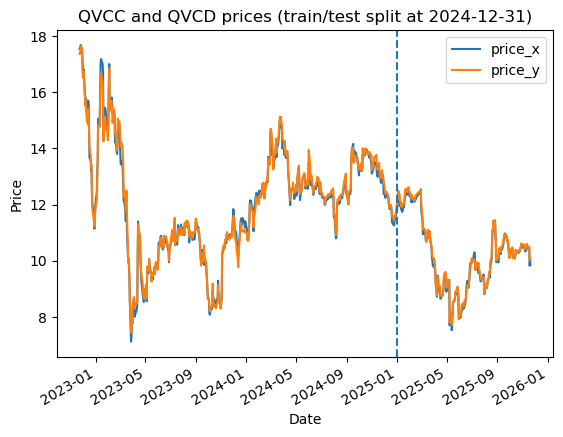

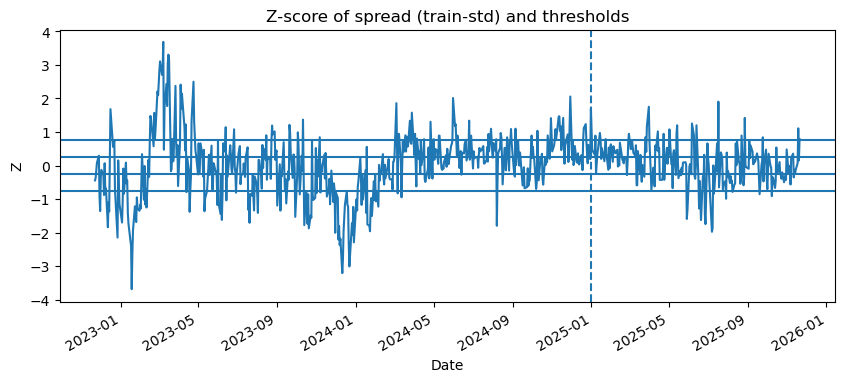

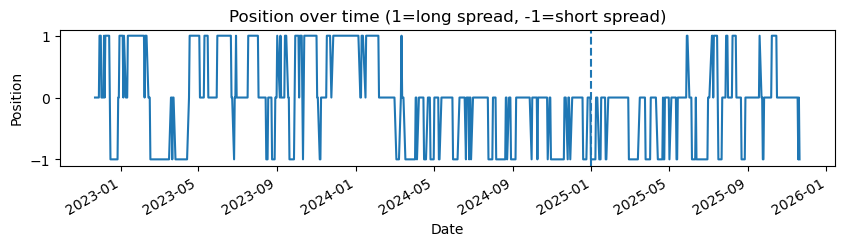

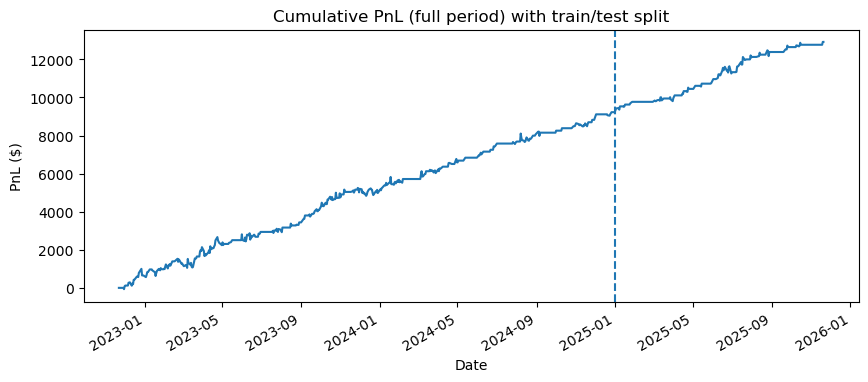

In [81]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ========= CONFIG =========
pair_s1 = "QVCC"
pair_s2 = "QVCD"

entry_z = 0.75   # enter when |z| > 2
exit_z  = 0.25   # exit when |z| < 0.5
notional = 10_000  # $10k notional per leg for scaling

train_end = "2024-12-31"  # train on 2022–2023, test on 2024+

# ========= BUILD SPREAD WITH TRAIN/TEST SPLIT =========

pair_prices = prices_clean[[pair_s1, pair_s2]].dropna().copy()

# train/test split by date
train_prices = pair_prices.loc[pair_prices.index < train_end]
test_prices  = pair_prices.loc[pair_prices.index >= train_end]

print("Train period:", train_prices.index.min(), "→", train_prices.index.max())
print("Test period :", test_prices.index.min(), "→", test_prices.index.max())

# 1) Estimate beta on TRAIN only (log prices)
log_x_train = np.log(train_prices[pair_s1])
log_y_train = np.log(train_prices[pair_s2])

X_train = sm.add_constant(log_x_train.values)
model_beta = sm.OLS(log_y_train.values, X_train).fit()
beta = model_beta.params[1]

print(f"Estimated beta on train: {beta:.4f}")

# 2) Build spread on FULL sample using train-estimated beta
log_x_full = np.log(pair_prices[pair_s1])
log_y_full = np.log(pair_prices[pair_s2])
spread_full = log_y_full - beta * log_x_full

# 3) Standardize using TRAIN mean and std
spread_train = spread_full.loc[train_prices.index]
spread_mean = spread_train.mean()
spread_std  = spread_train.std()

z_full = (spread_full - spread_mean) / spread_std

df = pd.DataFrame({
    "price_x": pair_prices[pair_s1],
    "price_y": pair_prices[pair_s2],
    "spread": spread_full,
    "z": z_full
})

# ========= SIGNALS (APPLIED TO FULL SERIES, BUT WE'LL SCORE TEST ONLY) =========
state = 0  # 0 = flat, 1 = long spread, -1 = short spread
positions = []

for t, row in df.iterrows():
    z_t = row["z"]

    if state == 0:
        if z_t > entry_z:
            state = -1  # short spread: short y, long x
        elif z_t < -entry_z:
            state = 1   # long spread: long y, short x
    else:
        # in a trade; exit when z comes back near 0
        if abs(z_t) < exit_z:
            state = 0

    positions.append(state)

df["position"] = positions

# ========= P&L =========
ret_x = df["price_x"].pct_change().fillna(0.0)
ret_y = df["price_y"].pct_change().fillna(0.0)

w_y = df["position"] * (notional / df["price_y"])
w_x = -df["position"] * beta * (notional / df["price_x"])

pnl = w_x.shift(1) * (df["price_x"] - df["price_x"].shift(1)) + \
      w_y.shift(1) * (df["price_y"] - df["price_y"].shift(1))

df["pnl"] = pnl.fillna(0.0)
df["cum_pnl"] = df["pnl"].cumsum()

# ========= PERFORMANCE TABLES: TRAIN vs TEST vs FULL =========
def perf_stats(sub):
    total_pnl = sub["pnl"].sum()
    avg_daily_pnl = sub["pnl"].mean()
    daily_pnl_std = sub["pnl"].std()
    sharpe = np.nan
    if daily_pnl_std > 0:
        sharpe = (avg_daily_pnl / daily_pnl_std) * np.sqrt(252)
    trades = (sub["position"].diff().abs() > 0).sum() / 2

    return {
        "total_pnl": total_pnl,
        "avg_daily_pnl": avg_daily_pnl,
        "daily_pnl_std": daily_pnl_std,
        "sharpe": sharpe,
        "trades": trades
    }

df_train = df.loc[df.index < train_end]
df_test  = df.loc[df.index >= train_end]
df_full  = df.copy()

summary = pd.DataFrame({
    "train": perf_stats(df_train),
    "test": perf_stats(df_test),
    "full": perf_stats(df_full)
}).T

print("\nPerformance summary (notional = $10k per leg):")
print(summary)

# ========= SIMPLE TABLE OF LAST FEW ROWS =========
print("\nTail of trading dataframe:")
print(df[["price_x", "price_y", "z", "position", "pnl", "cum_pnl"]].tail())

# ========= PLOTS =========

# 1) Prices
plt.figure(figsize=(10, 4))
df[["price_x", "price_y"]].plot()
plt.axvline(pd.to_datetime(train_end), linestyle="--")
plt.title(f"{pair_s1} and {pair_s2} prices (train/test split at {train_end})")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# 2) Z-score and position
plt.figure(figsize=(10, 4))
df["z"].plot()
plt.axhline(entry_z)
plt.axhline(-entry_z)
plt.axhline(exit_z)
plt.axhline(-exit_z)
plt.axvline(pd.to_datetime(train_end), linestyle="--")
plt.title(f"Z-score of spread (train-std) and thresholds")
plt.xlabel("Date")
plt.ylabel("Z")
plt.show()

plt.figure(figsize=(10, 2))
df["position"].plot()
plt.axvline(pd.to_datetime(train_end), linestyle="--")
plt.title("Position over time (1=long spread, -1=short spread)")
plt.xlabel("Date")
plt.ylabel("Position")
plt.show()

# 3) Cumulative PnL
plt.figure(figsize=(10, 4))
df["cum_pnl"].plot()
plt.axvline(pd.to_datetime(train_end), linestyle="--")
plt.title("Cumulative PnL (full period) with train/test split")
plt.xlabel("Date")
plt.ylabel("PnL ($)")
plt.show()


In [82]:
import statsmodels.api as sm

def backtest_pair(
    s1, s2,
    prices_clean,
    train_end="2023-12-31",
    entry_z=0.75,
    exit_z=0.25,
    notional=10_000
):
    pair_prices = prices_clean[[s1, s2]].dropna().copy()
    if pair_prices.empty:
        return None

    train_prices = pair_prices.loc[pair_prices.index < train_end]
    test_prices  = pair_prices.loc[pair_prices.index >= train_end]

    if len(train_prices) < 100 or len(test_prices) < 30:
        return None

    # beta on TRAIN
    log_x_train = np.log(train_prices[s1])
    log_y_train = np.log(train_prices[s2])

    X_train = sm.add_constant(log_x_train.values)
    model_beta = sm.OLS(log_y_train.values, X_train).fit()
    beta = model_beta.params[1]

    # spread on FULL sample
    log_x_full = np.log(pair_prices[s1])
    log_y_full = np.log(pair_prices[s2])
    spread_full = log_y_full - beta * log_x_full

    # z-score using TRAIN mean/std
    spread_train = spread_full.loc[train_prices.index]
    spread_mean = spread_train.mean()
    spread_std  = spread_train.std()

    z_full = (spread_full - spread_mean) / spread_std

    df = pd.DataFrame({
        "price_x": pair_prices[s1],
        "price_y": pair_prices[s2],
        "spread": spread_full,
        "z": z_full
    })

    # signals
    state = 0
    positions = []

    for t, row in df.iterrows():
        z_t = row["z"]
        if state == 0:
            if z_t > entry_z:
                state = -1
            elif z_t < -entry_z:
                state = 1
        else:
            if abs(z_t) < exit_z:
                state = 0
        positions.append(state)

    df["position"] = positions

    # PnL
    ret_x = df["price_x"].pct_change().fillna(0.0)
    ret_y = df["price_y"].pct_change().fillna(0.0)

    w_y = df["position"] * (notional / df["price_y"])
    w_x = -df["position"] * beta * (notional / df["price_x"])

    pnl = w_x.shift(1) * (df["price_x"] - df["price_x"].shift(1)) + \
          w_y.shift(1) * (df["price_y"] - df["price_y"].shift(1))

    df["pnl"] = pnl.fillna(0.0)
    df["cum_pnl"] = df["pnl"].cumsum()
    df["pair"] = f"{s1}_{s2}"

    return df


In [83]:
pair_results = []
for _, row in tradable.iterrows():
    s1, s2 = row["s1"], row["s2"]
    df_pair = backtest_pair(s1, s2, prices_clean)
    if df_pair is not None:
        pair_results.append(df_pair)

# Align all pair PnLs by date
all_pnl = pd.concat(
    [
        df.set_index(df.index)[["pnl"]]
          .rename(columns={"pnl": df["pair"].iloc[0]})
        for df in pair_results
    ],
    axis=1
).fillna(0.0)

# Equal capital per pair basket PnL
basket_pnl = all_pnl.sum(axis=1)
basket_cum_pnl = basket_pnl.cumsum()

basket_stats = {
    "total_pnl": basket_cum_pnl.iloc[-1],
    "avg_daily_pnl": basket_pnl.mean(),
    "daily_pnl_std": basket_pnl.std(),
}
basket_stats["sharpe"] = (
    basket_stats["avg_daily_pnl"] / basket_stats["daily_pnl_std"] * np.sqrt(252)
    if basket_stats["daily_pnl_std"] > 0 else np.nan
)

# ---- Turn into a clean table ----
basket_summary = (
    pd.DataFrame([basket_stats], index=["basket"])
      .rename(columns={
          "total_pnl": "Total PnL ($)",
          "avg_daily_pnl": "Avg Daily PnL ($)",
          "daily_pnl_std": "Daily PnL Std ($)",
          "sharpe": "Sharpe (ann.)"
      })
      .round(2)
)

print("Basket performance summary:")
display(basket_summary)  # in Jupyter; or just print(basket_summary) if not using display()

# Optional: peek at the cumulative PnL series
basket_cum_pnl.name = "basket_cum_pnl"
print("\nCumulative PnL (last 5 days):")
print(basket_cum_pnl.tail())


Basket performance summary:


,Total PnL ($),Avg Daily PnL ($),Daily PnL Std ($),Sharpe (ann.)
basket,74617.18,99.22,235.61,6.69



Cumulative PnL (last 5 days):
timestamp
2025-11-14 05:00:00+00:00    74021.135715
2025-11-17 05:00:00+00:00    74147.652447
2025-11-18 05:00:00+00:00    74298.097663
2025-11-19 05:00:00+00:00    74440.131460
2025-11-20 05:00:00+00:00    74617.180922
Name: basket_cum_pnl, dtype: float64


In [84]:
import numpy as np
import pandas as pd

# Make sure this matches what you used in backtest_pair
train_end = "2023-12-31"

def perf_stats_from_df(sub: pd.DataFrame):
    """Compute simple performance stats from a pair-level df slice."""
    if sub.empty:
        return {
            "total_pnl": np.nan,
            "avg_daily_pnl": np.nan,
            "daily_pnl_std": np.nan,
            "sharpe": np.nan,
            "trades": np.nan,
        }

    total_pnl = sub["pnl"].sum()
    avg_daily_pnl = sub["pnl"].mean()
    daily_pnl_std = sub["pnl"].std()

    if daily_pnl_std > 0:
        sharpe = (avg_daily_pnl / daily_pnl_std) * np.sqrt(252)
    else:
        sharpe = np.nan

    trades = (sub["position"].diff().abs() > 0).sum() / 2

    return {
        "total_pnl": total_pnl,
        "avg_daily_pnl": avg_daily_pnl,
        "daily_pnl_std": daily_pnl_std,
        "sharpe": sharpe,
        "trades": trades,
    }

pair_rows = []

for df_pair in pair_results:
    pair_name = df_pair["pair"].iloc[0]

    df_train = df_pair.loc[df_pair.index < train_end]
    df_test  = df_pair.loc[df_pair.index >= train_end]
    df_full  = df_pair

    stats_train = perf_stats_from_df(df_train)
    stats_test  = perf_stats_from_df(df_test)
    stats_full  = perf_stats_from_df(df_full)

    row = {
        "pair": pair_name,

        # FULL period
        "full_total_pnl": stats_full["total_pnl"],
        "full_sharpe": stats_full["sharpe"],
        "full_trades": stats_full["trades"],

        # TRAIN (2022–2023)
        "train_total_pnl": stats_train["total_pnl"],
        "train_sharpe": stats_train["sharpe"],
        "train_trades": stats_train["trades"],

        # TEST (2024+)
        "test_total_pnl": stats_test["total_pnl"],
        "test_sharpe": stats_test["sharpe"],
        "test_trades": stats_test["trades"],
    }

    pair_rows.append(row)

pair_perf = pd.DataFrame(pair_rows).set_index("pair")

# Sort by test Sharpe (out-of-sample) to see which pairs generalize best
pair_perf_sorted = pair_perf.sort_values("test_sharpe", ascending=False)

# Clean up formatting a bit
pair_perf_display = pair_perf_sorted.round(2)

print("Per-pair performance (sorted by test Sharpe):")
display(pair_perf_display.head(20))  # top 20; change as you like


Per-pair performance (sorted by test Sharpe):


,full_total_pnl,full_sharpe,full_trades,train_total_pnl,train_sharpe,train_trades,test_total_pnl,test_sharpe,test_trades
pair,,,,,,,,,
QVCC_QVCD,12627.50,2.87,68.0,4776.62,2.48,26.5,7850.88,3.24,41.5
BAC.PRO_BAC.PRP,3659.28,2.79,57.5,1496.50,3.04,21.5,2162.78,2.63,35.5
UZF_UZE,6490.78,2.48,67.5,3199.50,2.65,31.5,3291.27,2.43,36.0
JPM.PRK_JPM.PRL,2539.22,2.18,56.5,1024.51,2.07,22.5,1514.71,2.29,33.5
T.PRC_T.PRA,4322.86,2.52,47.5,2304.56,3.19,23.5,2018.29,2.05,24.0
COF.PRI_COF.PRJ,3264.24,2.08,42.5,1661.57,2.24,20.5,1602.67,2.05,22.0
COF.PRJ_COF.PRL,4377.03,2.07,32.5,2567.19,2.83,16.0,1809.84,1.53,16.5
COF.PRL_COF.PRN,3933.82,2.07,44.0,2216.01,2.90,24.0,1717.81,1.52,20.0
WFC.PRA_WFC.PRZ,2528.37,1.82,25.5,1491.69,2.36,13.5,1036.69,1.42,12.0


In [85]:
# all_pnl: index = date, columns = pair names, values = daily PnL per pair

# Correlation matrix of pair PnLs
pair_corr = all_pnl.corr()

print("Correlation matrix of pair daily PnL:")
display(pair_corr.round(2))


Correlation matrix of pair daily PnL:


,QVCC_QVCD,UZF_UZE,JPM.PRK_JPM.PRL,BAC.PRO_BAC.PRP,COF.PRI_COF.PRJ,T.PRC_T.PRA,CTBB_CTDD,WFC.PRC_WFC.PRD,WFC.PRA_WFC.PRZ,COF.PRJ_COF.PRN,COF.PRL_COF.PRN,TFC.PRO_TFC.PRR,COF.PRJ_COF.PRL,WFC.PRA_WFC.PRC,COF.PRI_COF.PRL,JPM.PRK_JPM.PRM,JPM.PRM_JPM.PRL,PBR_PBR.A,ASB_FNB
QVCC_QVCD,1.00,0.03,-0.01,0.00,-0.03,0.04,0.01,0.01,-0.01,-0.01,-0.03,-0.03,-0.02,0.01,-0.01,0.05,0.03,-0.03,0.02
UZF_UZE,0.03,1.00,0.05,0.01,0.05,0.09,0.02,-0.01,-0.02,-0.09,0.07,-0.04,-0.05,0.04,-0.00,-0.02,0.01,0.00,0.01
JPM.PRK_JPM.PRL,-0.01,0.05,1.00,0.02,-0.03,-0.02,-0.00,-0.07,0.03,-0.02,-0.05,0.04,0.08,0.01,0.03,-0.05,0.26,0.04,0.15
BAC.PRO_BAC.PRP,0.00,0.01,0.02,1.00,-0.02,0.03,-0.03,-0.01,0.08,-0.01,0.04,-0.02,0.07,0.05,0.09,0.07,0.08,-0.04,0.04
COF.PRI_COF.PRJ,-0.03,0.05,-0.03,-0.02,1.00,0.01,0.00,0.06,-0.00,-0.09,0.04,-0.02,-0.09,-0.05,0.04,-0.06,0.02,-0.02,-0.00
T.PRC_T.PRA,0.04,0.09,-0.02,0.03,0.01,1.00,-0.05,0.05,-0.08,-0.01,0.00,-0.04,-0.04,0.01,-0.00,-0.03,0.06,0.01,0.05
CTBB_CTDD,0.01,0.02,-0.00,-0.03,0.00,-0.05,1.00,0.04,0.06,0.04,-0.03,0.04,0.02,-0.01,-0.01,-0.03,-0.08,-0.05,0.03
WFC.PRC_WFC.PRD,0.01,-0.01,-0.07,-0.01,0.06,0.05,0.04,1.00,0.03,-0.05,0.07,0.05,-0.06,0.10,-0.07,0.04,0.04,-0.06,0.03
WFC.PRA_WFC.PRZ,-0.01,-0.02,0.03,0.08,-0.00,-0.08,0.06,0.03,1.00,-0.02,-0.04,0.12,-0.03,0.20,0.04,-0.01,0.01,-0.07,0.04
COF.PRJ_COF.PRN,-0.01,-0.09,-0.02,-0.01,-0.09,-0.01,0.04,-0.05,-0.02,1.00,-0.02,-0.01,0.36,0.06,0.16,0.00,0.01,0.02,0.06


In [86]:
# e.g., top 10 pairs by test Sharpe
top_n = 10
top_pairs = pair_perf_sorted.head(top_n).index.tolist()

sub_pnl = all_pnl[top_pairs]
pair_corr_top = sub_pnl.corr()

print(f"Correlation matrix of daily PnL for top {top_n} pairs:")
display(pair_corr_top.round(2))


Correlation matrix of daily PnL for top 10 pairs:


,QVCC_QVCD,BAC.PRO_BAC.PRP,UZF_UZE,JPM.PRK_JPM.PRL,T.PRC_T.PRA,COF.PRI_COF.PRJ,COF.PRJ_COF.PRL,COF.PRL_COF.PRN,WFC.PRA_WFC.PRZ,COF.PRJ_COF.PRN
QVCC_QVCD,1.00,0.00,0.03,-0.01,0.04,-0.03,-0.02,-0.03,-0.01,-0.01
BAC.PRO_BAC.PRP,0.00,1.00,0.01,0.02,0.03,-0.02,0.07,0.04,0.08,-0.01
UZF_UZE,0.03,0.01,1.00,0.05,0.09,0.05,-0.05,0.07,-0.02,-0.09
JPM.PRK_JPM.PRL,-0.01,0.02,0.05,1.00,-0.02,-0.03,0.08,-0.05,0.03,-0.02
T.PRC_T.PRA,0.04,0.03,0.09,-0.02,1.00,0.01,-0.04,0.00,-0.08,-0.01
COF.PRI_COF.PRJ,-0.03,-0.02,0.05,-0.03,0.01,1.00,-0.09,0.04,-0.00,-0.09
COF.PRJ_COF.PRL,-0.02,0.07,-0.05,0.08,-0.04,-0.09,1.00,0.15,-0.03,0.36
COF.PRL_COF.PRN,-0.03,0.04,0.07,-0.05,0.00,0.04,0.15,1.00,-0.04,-0.02
WFC.PRA_WFC.PRZ,-0.01,0.08,-0.02,0.03,-0.08,-0.00,-0.03,-0.04,1.00,-0.02
COF.PRJ_COF.PRN,-0.01,-0.01,-0.09,-0.02,-0.01,-0.09,0.36,-0.02,-0.02,1.00


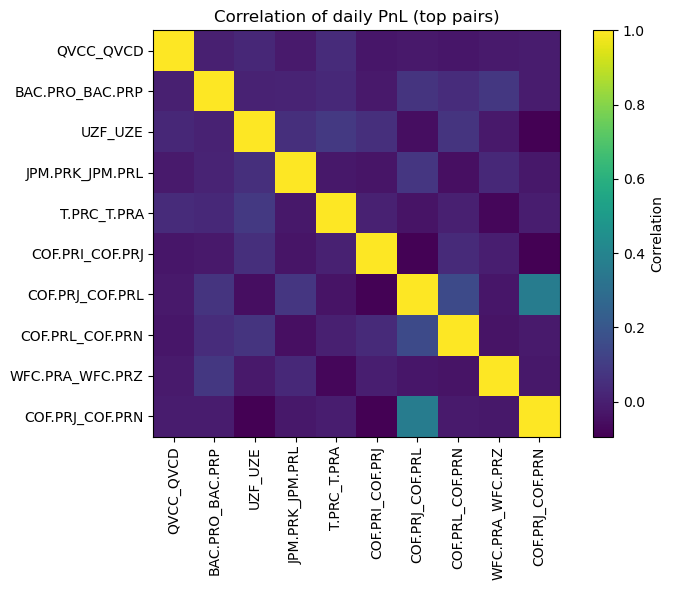

In [87]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
im = plt.imshow(pair_corr_top, interpolation="nearest")
plt.colorbar(im, label="Correlation")
plt.xticks(range(len(top_pairs)), top_pairs, rotation=90)
plt.yticks(range(len(top_pairs)), top_pairs)
plt.title("Correlation of daily PnL (top pairs)")
plt.tight_layout()
plt.show()


Factoring in Market Frictions

In [98]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def backtest_pair(
    s1, s2,
    prices_clean,
    train_end="2023-12-31",
    entry_z=0.75,
    exit_z=0.25,
    notional=10_000,
    cost_bps=2e-4,      # 2 bps per dollar traded (0.02%)
    borrow_rate=0.03    # 3% annualized borrow on the short leg
):
    """
    Backtest a single cointegrated pair with train/test split and frictions.

    - Train beta on data before train_end.
    - Build spread & z-score using train stats.
    - Trade on full period with:
        * Transaction costs on traded notional.
        * Borrow cost on short notional.
    """

    pair_prices = prices_clean[[s1, s2]].dropna().copy()
    if pair_prices.empty:
        return None

    # --- Train / test split ---
    train_prices = pair_prices.loc[pair_prices.index < train_end]
    test_prices  = pair_prices.loc[pair_prices.index >= train_end]

    # Need enough data
    if len(train_prices) < 100 or len(test_prices) < 30:
        return None

    # --- Estimate beta on TRAIN (log prices) ---
    log_x_train = np.log(train_prices[s1])
    log_y_train = np.log(train_prices[s2])

    X_train = sm.add_constant(log_x_train.values)
    model_beta = sm.OLS(log_y_train.values, X_train).fit()
    beta = model_beta.params[1]

    # --- Build spread on FULL sample ---
    log_x_full = np.log(pair_prices[s1])
    log_y_full = np.log(pair_prices[s2])
    spread_full = log_y_full - beta * log_x_full

    # --- Z-score using TRAIN mean/std ---
    spread_train = spread_full.loc[train_prices.index]
    spread_mean = spread_train.mean()
    spread_std  = spread_train.std()

    z_full = (spread_full - spread_mean) / spread_std

    df = pd.DataFrame({
        "price_x": pair_prices[s1],
        "price_y": pair_prices[s2],
        "spread": spread_full,
        "z": z_full
    })

    # --- Signals (same logic as before) ---
    state = 0  # 0 = flat, 1 = long spread, -1 = short spread
    positions = []

    for t, row in df.iterrows():
        z_t = row["z"]

        if state == 0:
            if z_t > entry_z:
                state = -1  # short spread: short y, long x
            elif z_t < -entry_z:
                state = 1   # long spread: long y, short x
        else:
            if abs(z_t) < exit_z:
                state = 0

        positions.append(state)

    df["position"] = positions

    # --- Position sizing (shares) ---
    ret_x = df["price_x"].pct_change().fillna(0.0)
    ret_y = df["price_y"].pct_change().fillna(0.0)

    # For state = 1 (long spread): long y, short x
    # For state = -1 (short spread): short y, long x
    w_y = df["position"] * (notional / df["price_y"])
    w_x = -df["position"] * beta * (notional / df["price_x"])

    # Previous day positions: used for PnL and borrow
    w_x_prev = w_x.shift(1)
    w_y_prev = w_y.shift(1)

    # --- Raw PnL from price moves ---
    raw_pnl = (
        w_x_prev * (df["price_x"] - df["price_x"].shift(1)) +
        w_y_prev * (df["price_y"] - df["price_y"].shift(1))
    )

    # --- Transaction costs on traded notional ---
    delta_x = (w_x - w_x_prev).abs()
    delta_y = (w_y - w_y_prev).abs()

    traded_notional = delta_x * df["price_x"] + delta_y * df["price_y"]
    tcost = cost_bps * traded_notional

    # --- Borrow cost on the short leg ---
    # If position = 1 (long spread): short x
    # If position = -1 (short spread): short y
    short_notional = np.where(
        df["position"] == 1,
        (w_x_prev.abs() * df["price_x"]),            # short x
        np.where(
            df["position"] == -1,
            (w_y_prev.abs() * df["price_y"]),        # short y
            0.0
        )
    )

    daily_borrow = borrow_rate / 252.0
    borrow_cost = daily_borrow * short_notional

    # --- Net PnL with frictions ---
    df["pnl"] = (raw_pnl - tcost - borrow_cost).fillna(0.0)
    df["cum_pnl"] = df["pnl"].cumsum()
    df["pair"] = f"{s1}_{s2}"

    return df


In [99]:
pair_results = []
for _, row in tradable.iterrows():
    s1, s2 = row["s1"], row["s2"]
    df_pair = backtest_pair(s1, s2, prices_clean)
    if df_pair is not None:
        pair_results.append(df_pair)

# Align all pair PnLs by date
all_pnl = pd.concat(
    [
        df.set_index(df.index)[["pnl"]]
          .rename(columns={"pnl": df["pair"].iloc[0]})
        for df in pair_results
    ],
    axis=1
).fillna(0.0)

# Equal capital per pair basket PnL
basket_pnl = all_pnl.sum(axis=1)
basket_cum_pnl = basket_pnl.cumsum()

basket_stats = {
    "total_pnl": basket_cum_pnl.iloc[-1],
    "avg_daily_pnl": basket_pnl.mean(),
    "daily_pnl_std": basket_pnl.std(),
}
basket_stats["sharpe"] = (
    basket_stats["avg_daily_pnl"] / basket_stats["daily_pnl_std"] * np.sqrt(252)
    if basket_stats["daily_pnl_std"] > 0 else np.nan
)

# ---- Turn into a clean table ----
basket_summary = (
    pd.DataFrame([basket_stats], index=["basket"])
      .rename(columns={
          "total_pnl": "Total PnL ($)",
          "avg_daily_pnl": "Avg Daily PnL ($)",
          "daily_pnl_std": "Daily PnL Std ($)",
          "sharpe": "Sharpe (ann.)"
      })
      .round(2)
)

print("Basket performance summary:")
display(basket_summary)  # in Jupyter; or just print(basket_summary) if not using display()

# Optional: peek at the cumulative PnL series
basket_cum_pnl.name = "basket_cum_pnl"
print("\nCumulative PnL (last 5 days):")
print(basket_cum_pnl.tail())

Basket performance summary:


,Total PnL ($),Avg Daily PnL ($),Daily PnL Std ($),Sharpe (ann.)
basket,58402.76,77.66,234.89,5.25



Cumulative PnL (last 5 days):
timestamp
2025-11-14 05:00:00+00:00    57880.233611
2025-11-17 05:00:00+00:00    57987.373432
2025-11-18 05:00:00+00:00    58114.997773
2025-11-19 05:00:00+00:00    58240.762247
2025-11-20 05:00:00+00:00    58402.763886
Name: basket_cum_pnl, dtype: float64
